# 03 — Preprocessing

In [ ]:
# --- Setup ---
import sys
sys.path.append('/content/drive/MyDrive/deepfake-detection')
from google.colab import drive
drive.mount('/content/drive')
from configs.paths import *

### Preprocessing

In [137]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader

In [138]:
index_path = PROC_ROOT / "ffpp_c23" / "splits" / "videos_index_ffpp_binary_component_split.csv"

df = pd.read_csv(index_path)

print("Total samples:", len(df))
df.head()

Total samples: 6000


,path,file,source_class,binary_label,binary_target,split,id_a,id_b,base_ids,dataset
0,/content/raw_datasets/ff-c23/FaceForensics++_C...,909.mp4,original,real,0,train,909,NaN,909,ffpp_c23_binary_component_split
1,/content/raw_datasets/ff-c23/FaceForensics++_C...,108.mp4,original,real,0,test,108,NaN,108,ffpp_c23_binary_component_split
2,/content/raw_datasets/ff-c23/FaceForensics++_C...,153.mp4,original,real,0,train,153,NaN,153,ffpp_c23_binary_component_split
3,/content/raw_datasets/ff-c23/FaceForensics++_C...,035.mp4,original,real,0,train,35,NaN,035,ffpp_c23_binary_component_split
4,/content/raw_datasets/ff-c23/FaceForensics++_C...,126.mp4,original,real,0,val,126,NaN,126,ffpp_c23_binary_component_split


In [139]:
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

print("Train samples:", len(train_df))
print("Val samples  :", len(val_df))
print("Test samples :", len(test_df))

Train samples: 4200
Val samples  : 900
Test samples : 900


In [140]:
NUM_FRAMES = 16
IMG_SIZE = 224
FACE_MARGIN = 0.20

MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

BATCH_SIZE = 16
NUM_WORKERS = 4   # safer in Colab for video reading

In [141]:
cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(cascade_path)

if face_cascade.empty():
    raise RuntimeError("Failed to load Haar cascade face detector.")

print("Face detector loaded successfully.")
print("Cascade path:", cascade_path)

Face detector loaded successfully.
Cascade path: /usr/local/lib/python3.12/dist-packages/cv2/data/haarcascade_frontalface_default.xml


In [142]:
MEAN = np.array([0.485,0.456,0.406])
STD  = np.array([0.229,0.224,0.225])

class DeepfakeBinaryDataset(Dataset):

    def __init__(self, df, frames_root, num_frames=16):
        self.df = df.reset_index(drop=True)
        self.frames_root = frames_root
        self.num_frames = num_frames

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        video_path = Path(row["path"])
        label = row["binary_target"]
        label_name = row["binary_label"]

        video_name = video_path.stem

        frame_dir = self.frames_root / label_name / video_name

        frames = []

        for i in range(self.num_frames):

            frame_path = frame_dir / f"frame_{i:02d}.jpg"

            img = cv2.imread(str(frame_path))

            if img is None:
                img = np.zeros((224,224,3))

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = img.astype(np.float32) / 255.0
            img = (img - MEAN) / STD
            img = np.transpose(img,(2,0,1))

            frames.append(img)

        frames = np.array(frames, dtype=np.float32)

        frames = torch.tensor(frames)

        label = torch.tensor(label).long()

        return frames, label

In [143]:
train_dataset = DeepfakeBinaryDataset(
    train_df,
    FRAMES_ROOT,
    num_frames=NUM_FRAMES,

)

val_dataset = DeepfakeBinaryDataset(
    val_df,
    FRAMES_ROOT,
    num_frames=NUM_FRAMES,

)

test_dataset = DeepfakeBinaryDataset(
    test_df,
    FRAMES_ROOT,
    num_frames=NUM_FRAMES,

)

print("Train dataset:", len(train_dataset))
print("Val dataset  :", len(val_dataset))
print("Test dataset :", len(test_dataset))

Train dataset: 4200
Val dataset  : 900
Test dataset : 900


In [144]:
sample_frames_tensor, sample_label = train_dataset[0]

print("Frames shape:", sample_frames_tensor.shape)   # (T, C, H, W)
print("Label:", sample_label.item())                # 0 = real, 1 = fake

Frames shape: torch.Size([16, 3, 224, 224])
Label: 0


In [145]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Dataloaders created successfully.")

Dataloaders created successfully.


In [146]:
batch_frames, batch_labels = next(iter(train_loader))

print("Batch frames shape:", batch_frames.shape)   # (B, T, C, H, W)
print("Batch labels shape:", batch_labels.shape)
print("Batch labels:", batch_labels)

Batch frames shape: torch.Size([16, 16, 3, 224, 224])
Batch labels shape: torch.Size([16])
Batch labels: tensor([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1])


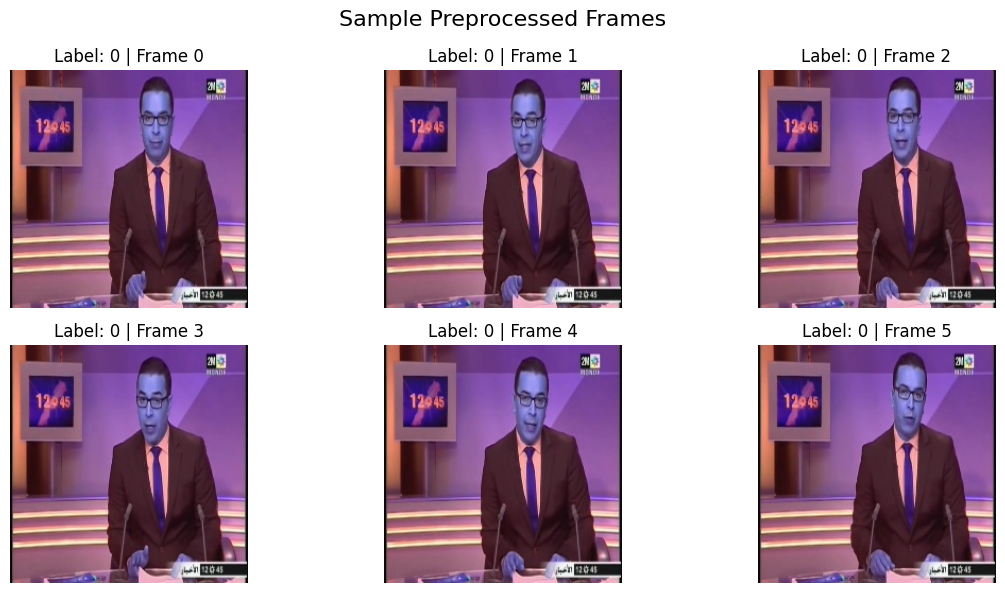

In [147]:
frames_tensor, label_tensor = train_dataset[0]

frames_np = frames_tensor.detach().cpu().numpy()
frames_np = np.transpose(frames_np, (0, 2, 3, 1))   # (T, C, H, W) -> (T, H, W, C)
frames_np = (frames_np * STD) + MEAN
frames_np = np.clip(frames_np, 0, 1)

plt.figure(figsize=(12, 6))
for i in range(min(6, len(frames_np))):
    plt.subplot(2, 3, i + 1)
    plt.imshow(frames_np[i])
    plt.title(f"Label: {label_tensor.item()} | Frame {i}")
    plt.axis("off")

plt.suptitle("Sample Preprocessed Frames", fontsize=16)
plt.tight_layout()
plt.show()

In [148]:
sample_row = train_df.sample(1, random_state=42).iloc[0]
video_path = sample_row["path"]

print("Sample video:", video_path)

cap = cv2.VideoCapture(str(video_path))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames // 2)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError("Could not read sample frame from video.")

frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

print("Frame shape:", frame.shape)
print("Binary label:", sample_row["binary_label"])
print("Source class:", sample_row["source_class"])

Sample video: /content/raw_datasets/ff-c23/FaceForensics++_C23/FaceShifter/912_927.mp4
Frame shape: (480, 640, 3)
Binary label: fake
Source class: FaceShifter


In [149]:
gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(40, 40)
)

frame_with_box = frame.copy()

if len(faces) > 0:
    faces = sorted(faces, key=lambda b: b[2] * b[3], reverse=True)
    x, y, w, h = faces[0]

    cv2.rectangle(frame_with_box, (x, y), (x + w, y + h), (255, 0, 0), 3)

    mx = int(w * FACE_MARGIN)
    my = int(h * FACE_MARGIN)

    x1 = max(0, x - mx)
    y1 = max(0, y - my)
    x2 = min(frame.shape[1], x + w + mx)
    y2 = min(frame.shape[0], y + h + my)

    face_crop = frame[y1:y2, x1:x2]
else:
    face_crop = frame

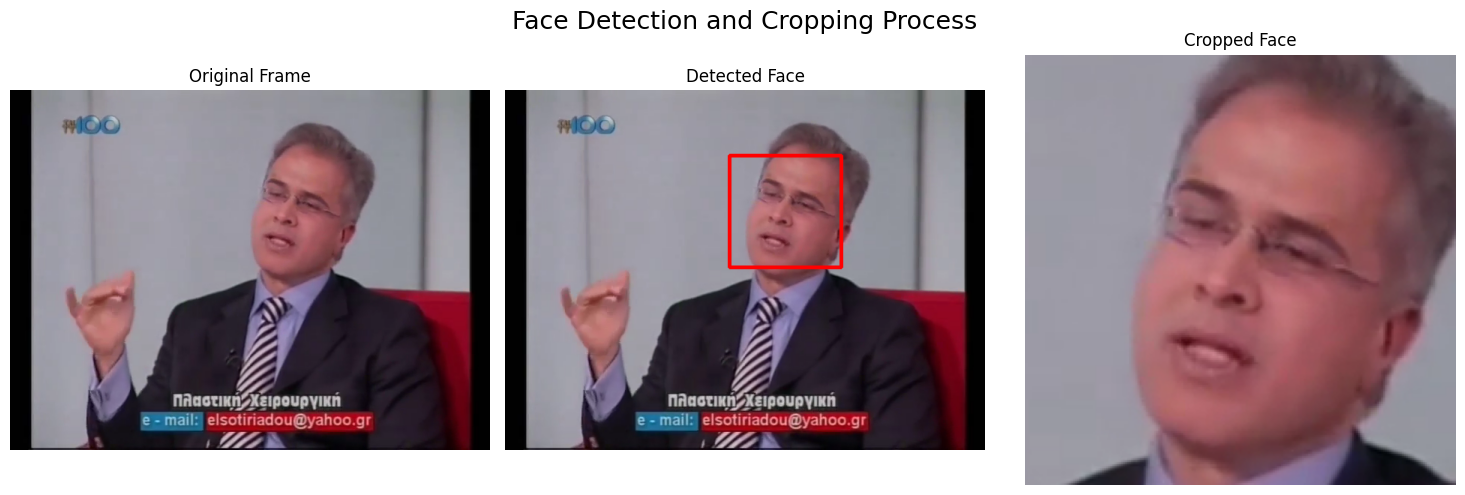

In [150]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(frame)
plt.title("Original Frame")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(frame_with_box)
plt.title("Detected Face")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(face_crop)
plt.title("Cropped Face")
plt.axis("off")

plt.suptitle("Face Detection and Cropping Process", fontsize=18)
plt.tight_layout()
plt.show()